## Airbnb Price Prediction and Insights

In [204]:
#Import all the necessary Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [205]:
data = pd.read_csv("Airbnb_data - airbnb_data.csv") #Load the dataset

## Data Preprocessing

In [206]:
data.head() # print first five rows

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,...,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,...,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,...,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,...,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,...,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [207]:
data.tail() #print last five rows

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,...,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
74106,14549287,4.605170,Apartment,Private room,{},1,1.0,Real Bed,flexible,False,...,40.709025,-73.939405,one room bushwick,Williamsburg,0,NaN,https://a0.muscache.com/im/pictures/55162426/6...,11206,1.0,1.0
74107,13281809,5.043425,Apartment,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,2.0,Real Bed,moderate,True,...,33.871549,-118.396053,Spacious Hermosa 2 BR on PCH,Hermosa Beach,16,93.0,https://a0.muscache.com/im/pictures/2b86560b-a...,90254,2.0,4.0
74108,18688039,5.220356,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",5,1.0,Real Bed,moderate,True,...,40.706749,-73.942377,Modern 2 Bedroom Apartment in Williamsburg,Williamsburg,43,94.0,https://a0.muscache.com/im/pictures/7fbe448c-5...,11206,2.0,2.0
74109,17045948,5.273000,Apartment,Entire home/apt,"{TV,""Wireless Internet"",""Air conditioning"",Kit...",2,1.0,Real Bed,strict,True,...,40.738535,-74.000157,Designer's Apartment in HEART of NYC,West Village,0,NaN,https://a0.muscache.com/im/pictures/b3971b63-0...,10011,0.0,2.0
74110,3534845,4.852030,Boat,Entire home/apt,"{TV,Internet,""Wireless Internet"",Kitchen,""Free...",4,1.0,Real Bed,moderate,False,...,33.761096,-118.192409,Cozy Boat at Shoreline Village,Long Beach,205,96.0,https://a0.muscache.com/im/pictures/22968537/d...,90802,1.0,2.0


In [208]:
data.iloc[0:5,10:29] #prints first five rows along with 10 to 28 columns to better understand the data

,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",18-06-2016,t,t,NaN,26-03-2012,f,18-07-2016,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,NYC,Enjoy travelling during your stay in Manhattan...,05-08-2017,t,f,100%,19-06-2017,t,23-09-2017,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,NYC,The Oasis comes complete with a full backyard ...,30-04-2017,t,t,100%,25-10-2016,t,14-09-2017,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,19-04-2015,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117,2.0,2.0
4,DC,"Cool, cozy, and comfortable studio located in ...",12-05-2015,t,t,100%,01-03-2015,t,22-01-2017,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


## Exploratory Data Analysis

In [209]:
#Summary of the dataset
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74111 entries, 0 to 74110
Data columns (total 29 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      74111 non-null  int64  
 1   log_price               74111 non-null  float64
 2   property_type           74111 non-null  object 
 3   room_type               74111 non-null  object 
 4   amenities               74111 non-null  object 
 5   accommodates            74111 non-null  int64  
 6   bathrooms               73911 non-null  float64
 7   bed_type                74111 non-null  object 
 8   cancellation_policy     74111 non-null  object 
 9   cleaning_fee            74111 non-null  bool   
 10  city                    74111 non-null  object 
 11  description             74111 non-null  object 
 12  first_review            58247 non-null  object 
 13  host_has_profile_pic    73923 non-null  object 
 14  host_identity_verified  73923 non-null

In [210]:
#Statistical Summary of the dataset containing all columns
data.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
id,74111.0,NaN,NaN,NaN,11266617.102468,6081734.886894,344.0,6261964.5,12254147.0,16402260.5,21230903.0
log_price,74111.0,NaN,NaN,NaN,4.782069,0.717394,0.0,4.317488,4.70953,5.220356,7.600402
property_type,74111,35,Apartment,49003,NaN,NaN,NaN,NaN,NaN,NaN,NaN
room_type,74111,3,Entire home/apt,41310,NaN,NaN,NaN,NaN,NaN,NaN,NaN
amenities,74111,67122,{},586,NaN,NaN,NaN,NaN,NaN,NaN,NaN
accommodates,74111.0,NaN,NaN,NaN,3.155146,2.153589,1.0,2.0,2.0,4.0,16.0
bathrooms,73911.0,NaN,NaN,NaN,1.235263,0.582044,0.0,1.0,1.0,1.0,8.0
bed_type,74111,5,Real Bed,72028,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cancellation_policy,74111,5,strict,32374,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cleaning_fee,74111,2,True,54403,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [211]:
#Prints total null values in each column, besides percentage of missing value in the dataset
null_value = data.isnull().sum() #finds total null values
percentage_values = (data.isnull().sum() / len(data) ) * 100 #calculated percentage of missing values
missing_values = pd.concat([null_value, percentage_values], axis = 1, keys = ['Missing Values', 'Percentage']) #Concating two variables
missing_values

,Missing Values,Percentage
id,0,0.000000
log_price,0,0.000000
property_type,0,0.000000
room_type,0,0.000000
amenities,0,0.000000
accommodates,0,0.000000
bathrooms,200,0.269865
bed_type,0,0.000000
cancellation_policy,0,0.000000
cleaning_fee,0,0.000000


In [212]:
#Dropping the columns as they have no influence on target feature
data.drop(columns = ['id', 'description','first_review','latitude', 'longitude','thumbnail_url', 'zipcode', 'last_review', 
                    'host_has_profile_pic', 'host_identity_verified'], axis = 1, inplace = True)

In [213]:
data.dtypes

log_price               float64
property_type            object
room_type                object
amenities                object
accommodates              int64
bathrooms               float64
bed_type                 object
cancellation_policy      object
cleaning_fee               bool
city                     object
host_response_rate       object
host_since               object
instant_bookable         object
name                     object
neighbourhood            object
number_of_reviews         int64
review_scores_rating    float64
bedrooms                float64
beds                    float64
dtype: object

In [214]:
#value counts for Amenities column
data.amenities

0        {"Wireless Internet","Air conditioning",Kitche...
1        {"Wireless Internet","Air conditioning",Kitche...
2        {TV,"Cable TV","Wireless Internet","Air condit...
3        {TV,"Cable TV",Internet,"Wireless Internet",Ki...
4        {TV,Internet,"Wireless Internet","Air conditio...
                               ...                        
74106                                                   {}
74107    {TV,"Cable TV",Internet,"Wireless Internet",Ki...
74108    {TV,Internet,"Wireless Internet","Air conditio...
74109    {TV,"Wireless Internet","Air conditioning",Kit...
74110    {TV,Internet,"Wireless Internet",Kitchen,"Free...
Name: amenities, Length: 74111, dtype: object

In [215]:
#Converting Total amenities into len of amenities
amenities_count = []
for i in data.amenities:
    amenities_count.append(len(i))

In [216]:
#Assigning to the Amenities column
data['amenities'] = amenities_count

In [217]:
categorical_cols = data.select_dtypes(include = ['object','category']).columns.to_list() # Categorical Variables
numerical_cols = data.select_dtypes(include = ['number']).columns.to_list() # Numerical Variables

In [218]:
#List of Both Categorical and Numerical Columns 
print('Categorical Columns:\n {}'.format(categorical_cols))
print('\nNumerical Columns:\n {}'.format(numerical_cols))

Categorical Columns:
 ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'host_response_rate', 'host_since', 'instant_bookable', 'name', 'neighbourhood']

Numerical Columns:
 ['log_price', 'amenities', 'accommodates', 'bathrooms', 'number_of_reviews', 'review_scores_rating', 'bedrooms', 'beds']


In [219]:
#Central Tendency Values For Bathrooms column

print(f'Mean: {data['bathrooms'].mean()}')
print(f'Median: {data['bathrooms'].median()}')
print(f'Mode: {data['bathrooms'].mode()}')

Mean: 1.235262680791763
Median: 1.0
Mode: 0    1.0
Name: bathrooms, dtype: float64


In [220]:
#Most Frequent Response Rate of Host
print(f'Mode {data['host_response_rate'].mode()}')

Mode 0    100%
Name: host_response_rate, dtype: object


In [221]:
#Most Visited Neighbourhood
print(f'Mode: {data['neighbourhood'].mode()}')

Mode: 0    Williamsburg
Name: neighbourhood, dtype: object


In [222]:
#Central Tendency Values For Review Score Rating column

print(f'Mean: {data['review_scores_rating'].mean()}')
print(f'Median: {data['review_scores_rating'].median()}')
print(f'Mode: {data['review_scores_rating'].mode()}')

Mean: 94.06736482601195
Median: 96.0
Mode: 0    100.0
Name: review_scores_rating, dtype: float64


In [223]:
#Central Tendency Values For Bedroom column

print(f'Mean: {data['bedrooms'].mean()}')
print(f'Median: {data['bedrooms'].median()}')
print(f'Mode: {data['bedrooms'].mode()}')

Mean: 1.265793028911105
Median: 1.0
Mode: 0    1.0
Name: bedrooms, dtype: float64


In [224]:
#Central Tendency Values For Bed column

print(f'Mean: {data['beds'].mean()}')
print(f'Median: {data['beds'].median()}')
print(f'Mode: {data['beds'].mode()}')

Mean: 1.710867802108678
Median: 1.0
Mode: 0    1.0
Name: beds, dtype: float64


In [225]:
#Imputing Bedrooms, Beds, Bathrooms, Review Score Rating Columns with Median

data['bedrooms'].fillna(data['bedrooms'].median(), inplace = True)
data['beds'].fillna(data['beds'].median(), inplace = True)
data['bathrooms'].fillna(data['bathrooms'].median(), inplace = True)
data['review_scores_rating'].fillna(data['review_scores_rating'].median(), inplace = True)

In [226]:
#Imputing Host Resonse Rate with 70%, & Neighbourhood, Host Since, Host has Profile Pic, Host identity verified with mode

data['host_response_rate'].fillna('70%', inplace = True)
data['neighbourhood'].fillna(data['neighbourhood'].mode()[0], inplace = True)
data['host_since'].fillna(data['host_since'].mode()[0], inplace = True)
# data['host_has_profile_pic'].fillna(data['host_has_profile_pic'].mode()[0], inplace = True)
# data['host_identity_verified'].fillna(data['host_identity_verified'].mode()[0], inplace = True)

In [227]:
# Convert Host Since to datetime and extract Year from it

data['host_since'] = pd.to_datetime(data['host_since'])
data['host_year'] = data['host_since'].dt.year
data['host_year']

0        2012
1        2017
2        2016
3        2015
4        2015
         ... 
74106    2013
74107    2016
74108    2012
74109    2017
74110    2012
Name: host_year, Length: 74111, dtype: int32

In [228]:
# Dropping Host Since Column
data.drop('host_since', axis = 1,  inplace = True)

In [229]:
data.isna().sum() # Total Null Values in the dataset

log_price               0
property_type           0
room_type               0
amenities               0
accommodates            0
bathrooms               0
bed_type                0
cancellation_policy     0
cleaning_fee            0
city                    0
host_response_rate      0
instant_bookable        0
name                    0
neighbourhood           0
number_of_reviews       0
review_scores_rating    0
bedrooms                0
beds                    0
host_year               0
dtype: int64

In [230]:
data['host_response_rate'] = data['host_response_rate'].str.rstrip('%').astype(int) # stripping '%' and Convert into integer

data['instant_bookable'] = data['instant_bookable'].map({'t':1,'f':0}) # Mapping t with 1 and f with 0
data['cleaning_fee'] = data['cleaning_fee'].replace({'True':1,'False':0}).astype(int) # replacing and converting into integer

In [231]:
# Replace erroneos
data['name'] = data['name'].replace({'#NAME?':'Unknown'})

In [232]:
data.isna().sum().sum()

0

## Handling Outliers

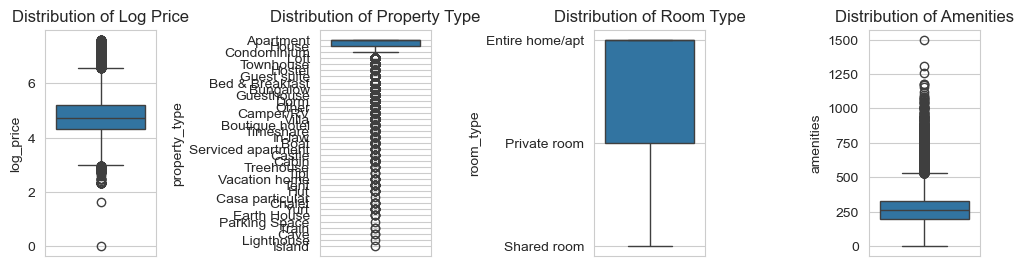

In [233]:
plt.figure(figsize = (10,10))
plt.subplot(4,4,1)
sns.boxplot(data['log_price']) #Box Plot of Log Price
plt.title('Distribution of Log Price')

plt.subplot(4,4,2)
sns.boxplot(data['property_type']) # Box Plot of Propert Type
plt.title('Distribution of Property Type')

plt.subplot(4,4,3)  
sns.boxplot(data['room_type']) #Box Plot of Room Type
plt.title('Distribution of Room Type')

plt.subplot(4,4,4)
sns.boxplot(data['amenities']) # Box Plot of Amenities
plt.title('Distribution of Amenities')

plt.tight_layout()
plt.show()

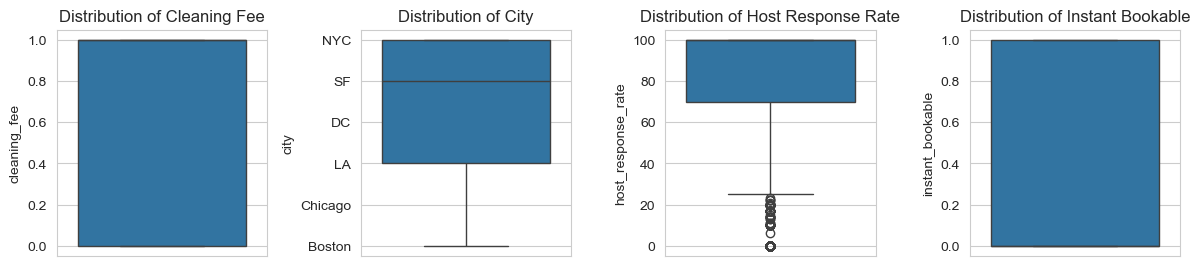

In [234]:
plt.figure(figsize = (12,10))
plt.subplot(4,4,1)
sns.boxplot(data['cleaning_fee']) # Box Plot of Cleaning Fee
plt.title('Distribution of Cleaning Fee')

plt.subplot(4,4,2)
sns.boxplot(data['city']) # Box Plot of City
plt.title('Distribution of City')

plt.subplot(4,4,3)
sns.boxplot(data['host_response_rate']) # Box Plot of Host Response Rate
plt.title('Distribution of Host Response Rate')

plt.subplot(4,4,4)
sns.boxplot(data['instant_bookable']) # Box Plot of Instant Bookable
plt.title('Distribution of Instant Bookable')

plt.tight_layout()
plt.show()

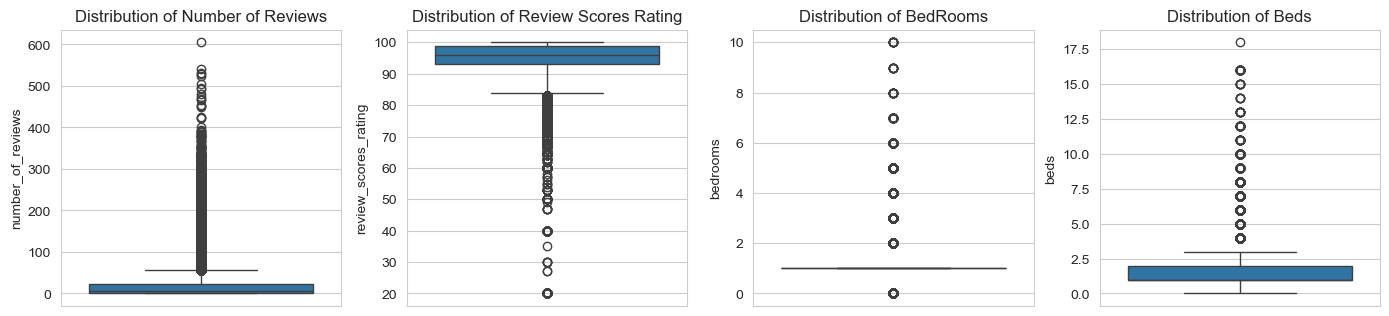

In [235]:
plt.figure(figsize = (14,12))
plt.subplot(4,4,1)
sns.boxplot(data['number_of_reviews']) # Box Plot of Number of Reviews
plt.title('Distribution of Number of Reviews')

plt.subplot(4,4,2)
sns.boxplot(data['review_scores_rating']) # Box Plot of Review Scores Rating
plt.title('Distribution of Review Scores Rating')

plt.subplot(4,4,3)
sns.boxplot(data['bedrooms']) # Box Plot of Bed Rooms
plt.title('Distribution of BedRooms')

plt.subplot(4,4,4)
sns.boxplot(data['beds']) # Box Plot of Beds
plt.title('Distribution of Beds')


plt.tight_layout()
plt.show()

#### Handling Outliers For Log Price

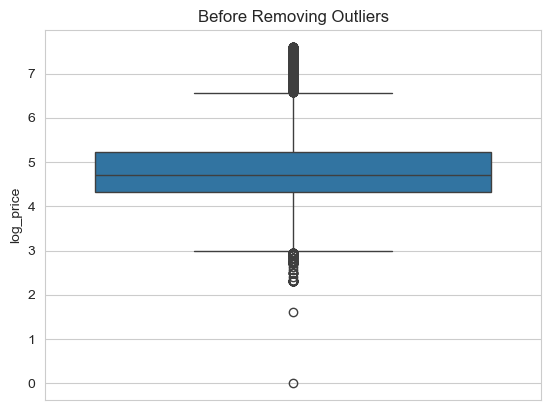

In [236]:
#Box Plot before Removing the outliers

sns.boxplot(data['log_price'])
plt.title("Before Removing Outliers")
plt.show()

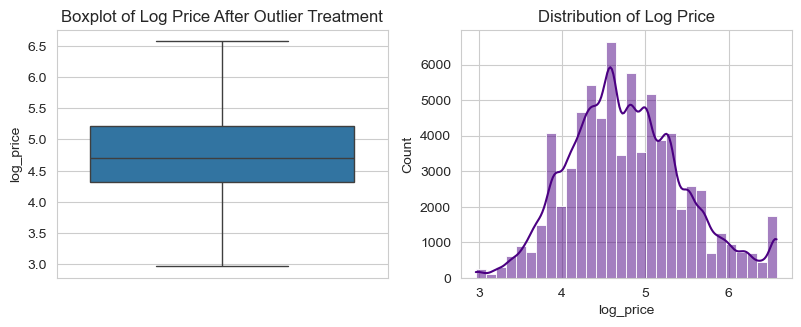

In [237]:
Q1 = data['log_price'].quantile(0.25)
Q3 = data['log_price'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['log_price'] = data['log_price'].clip(lower=lower_bound, upper=upper_bound) # Using Clip method to remove outliers
plt.figure(figsize = (8,6))
plt.subplot(2,2,1) #Subplot for Box Plot
sns.boxplot(data['log_price'])
plt.title('Boxplot of Log Price After Outlier Treatment')


plt.subplot(2,2,2) # Subplot for Hist Plot
sns.histplot(data['log_price'], bins = 30, kde = True, color = 'indigo')
plt.title("Distribution of Log Price")

plt.tight_layout()
plt.show()

#### Handling Outliers For Amenities

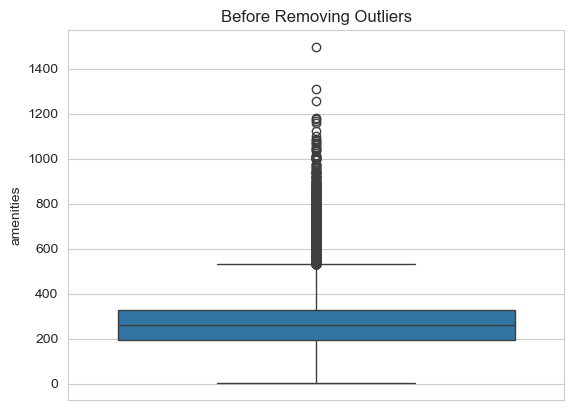

In [238]:
#Box Plot before Removing the outliers

sns.boxplot(data['amenities'])
plt.title("Before Removing Outliers")
plt.show()

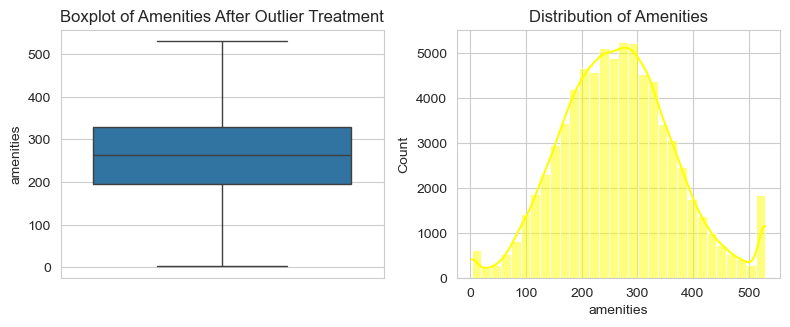

In [239]:
Q1 = data['amenities'].quantile(0.25)
Q3 = data['amenities'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['amenities'] = data['amenities'].clip(lower=lower_bound, upper=upper_bound)  # Using Clip method to remove outliers

plt.figure(figsize=(8,6))
plt.subplot(2,2,1) #Subplot for Box Plot
sns.boxplot(data['amenities'])
plt.title('Boxplot of Amenities After Outlier Treatment')

plt.subplot(2,2,2) # Subplot for Hist Plot
sns.histplot(data['amenities'], bins = 30, kde = True, color = 'Yellow')
plt.title("Distribution of Amenities")

plt.tight_layout()
plt.show()

#### Handling Outliers For Host Response Rate

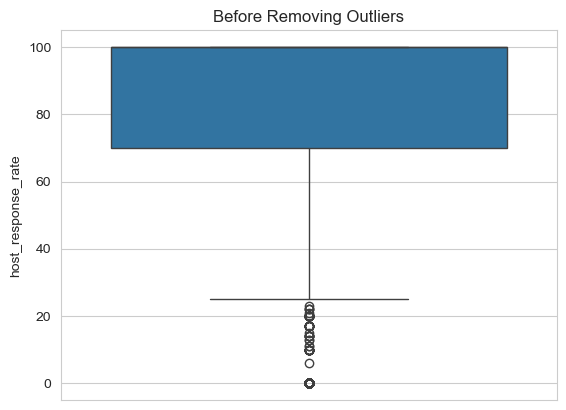

In [240]:
#Box Plot before Removing the outliers

sns.boxplot(data['host_response_rate'])
plt.title("Before Removing Outliers")
plt.show()

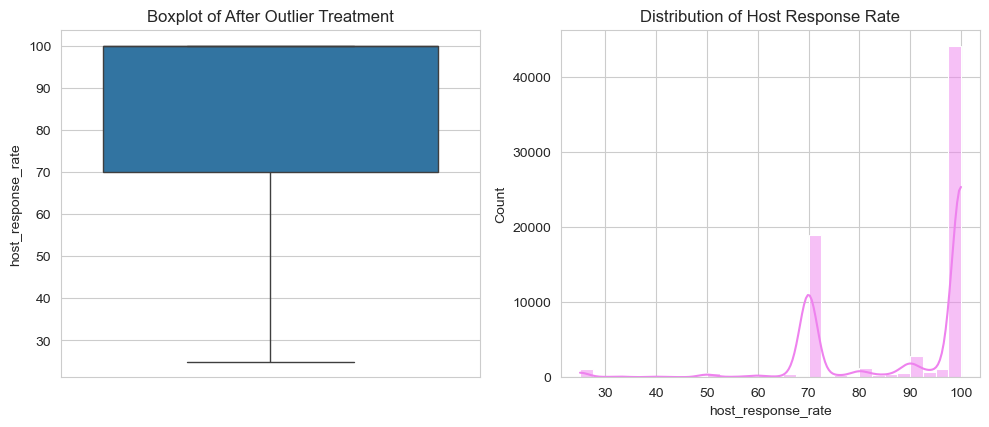

In [241]:
Q1 = data['host_response_rate'].quantile(0.25)
Q3 = data['host_response_rate'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['host_response_rate'] = data['host_response_rate'].clip(lower=lower_bound, upper=upper_bound)  # Using Clip method to remove outliers

plt.figure(figsize=(10,8))
plt.subplot(2,2,1)  #Subplot for Box Plot
sns.boxplot(data['host_response_rate'])
plt.title('Boxplot of After Outlier Treatment')

plt.subplot(2,2,2) # Subplot for Hist Plot
sns.histplot(data['host_response_rate'], bins = 30, kde = True, color = 'Violet')
plt.title("Distribution of Host Response Rate")

plt.tight_layout()
plt.show()

#### Handling Outliers Foor Number Of Reviews

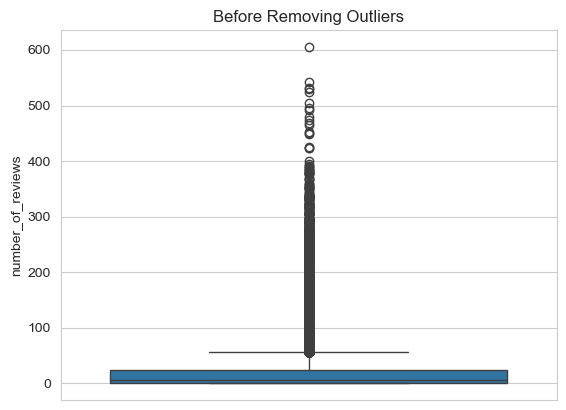

In [242]:
#Box Plot before Removing the outliers

sns.boxplot(data['number_of_reviews'])
plt.title("Before Removing Outliers")
plt.show()

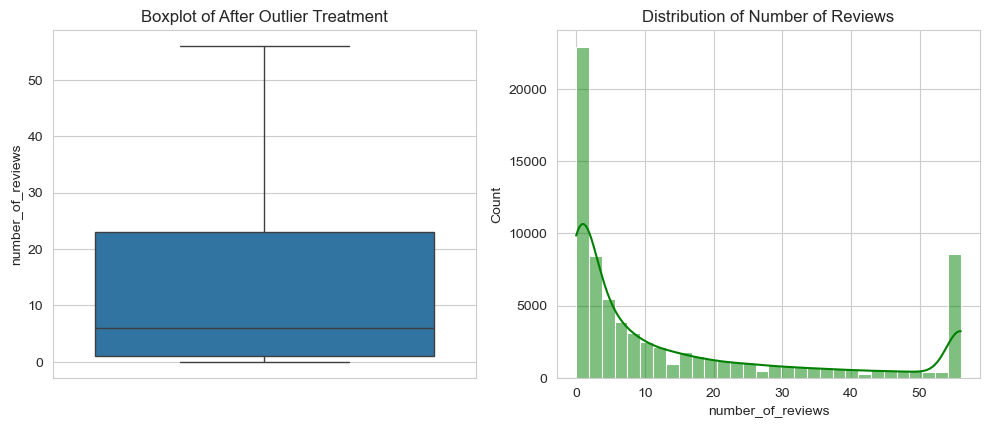

In [243]:
Q1 = data['number_of_reviews'].quantile(0.25)
Q3 = data['number_of_reviews'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['number_of_reviews'] = data['number_of_reviews'].clip(lower=lower_bound, upper=upper_bound)  # Using Clip method to remove outliers

plt.figure(figsize=(10,8))
plt.subplot(2,2,1) #Subplot for Box Plot
sns.boxplot(data['number_of_reviews'])
plt.title('Boxplot of After Outlier Treatment')

plt.subplot(2,2,2) # Subplot for Hist Plot
sns.histplot(data['number_of_reviews'], bins = 30, kde = True, color = 'Green')
plt.title("Distribution of Number of Reviews")

plt.tight_layout()
plt.show()

#### Handling Outliers For Review Scores Ratings

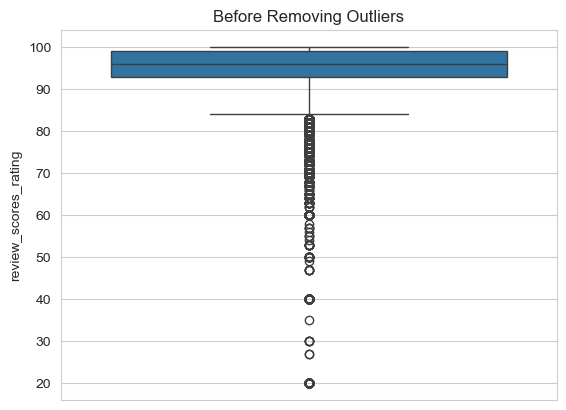

In [244]:
#Box Plot before Removing the outliers

sns.boxplot(data['review_scores_rating'])
plt.title("Before Removing Outliers")
plt.show()

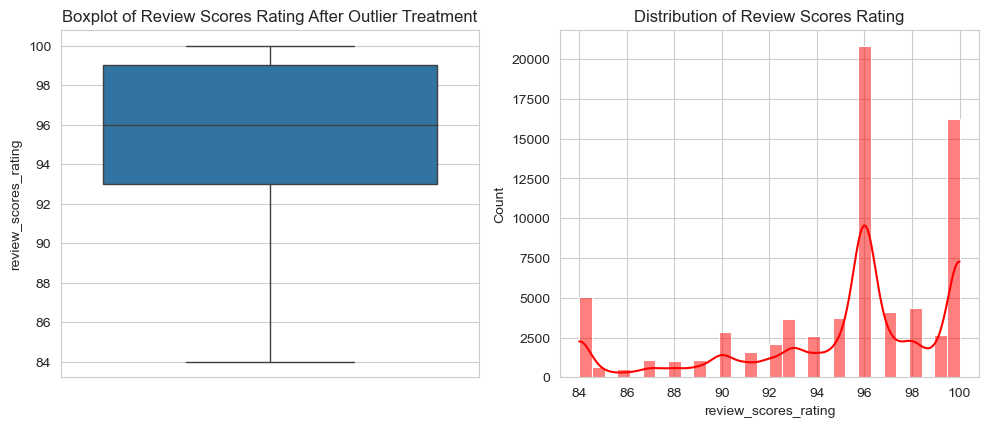

In [245]:
Q1 = data['review_scores_rating'].quantile(0.25)
Q3 = data['review_scores_rating'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['review_scores_rating'] = data['review_scores_rating'].clip(lower=lower_bound, upper=upper_bound)  # Using Clip method to remove outliers

plt.figure(figsize=(10,8))
plt.subplot(2,2,1) #Subplot for Box Plot
sns.boxplot(data['review_scores_rating'])
plt.title('Boxplot of Review Scores Rating After Outlier Treatment')

plt.subplot(2,2,2) # Subplot for Hist Plot
sns.histplot(data['review_scores_rating'], bins = 30, kde = True, color = 'Red')
plt.title("Distribution of Review Scores Rating")

plt.tight_layout()
plt.show()

#### Handling Outliers For Accommodates

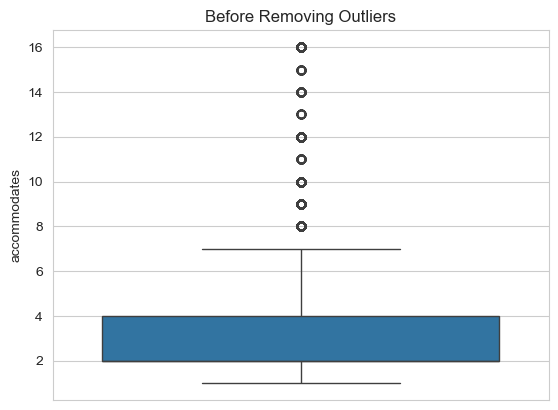

In [246]:
#Box Plot before Removing the outliers

sns.boxplot(data['accommodates'])
plt.title("Before Removing Outliers")
plt.show()

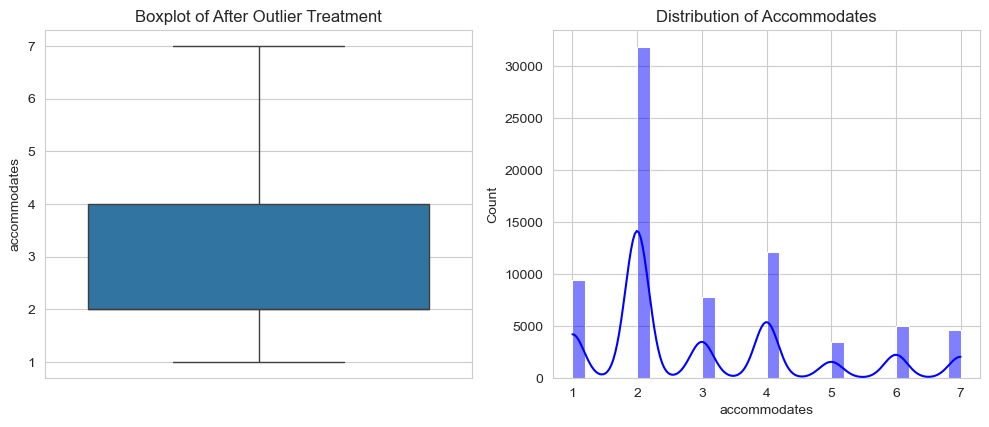

In [247]:
Q1 = data['accommodates'].quantile(0.25)
Q3 = data['accommodates'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
data['accommodates'] = data['accommodates'].clip(lower=lower_bound, upper=upper_bound)  # Using Clip method to remove outliers

plt.figure(figsize=(10,8))
plt.subplot(2,2,1) #Subplot for Box Plot
sns.boxplot(data['accommodates'])
plt.title('Boxplot of After Outlier Treatment')

plt.subplot(2,2,2) # Subplot for Hist Plot
sns.histplot(data['accommodates'], bins = 30, kde = True, color = 'Blue')
plt.title("Distribution of Accommodates")
           
plt.tight_layout()
plt.show()

## Data Exploration

In [248]:
#Room Types based on Avg Price using Groupby
top_rooms = data.groupby("room_type")["log_price"].mean().round(2).sort_values(ascending=False).head(10).reset_index()
top_rooms

,room_type,log_price
0,Entire home/apt,5.16
1,Private room,4.33
2,Shared room,3.87


##### Here, We can see that For Home or Apartment the avg price is higher, For Private Room Moderate, and For Shared Room It is Low which is, 3.87.

In [249]:
#Top 10 Property Types based on Avg Price using Groupby

top10_properties_avg_log_price = data.groupby("property_type")["log_price"].mean().round(2).head(10).sort_values(ascending=False).reset_index()
top10_properties_avg_log_price

,property_type,log_price
0,Castle,5.37
1,Boat,5.17
2,Boutique hotel,5.05
3,Cave,4.91
4,Bungalow,4.78
5,Apartment,4.76
6,Cabin,4.65
7,Camper/RV,4.60
8,Bed & Breakfast,4.55
9,Casa particular,4.38


#### Here, Top 10 Properties are diaplayed, where castle is higher price and casa particular is lower price

In [250]:
#Cancellation Policy based on Avg Price using Groupby

cancellation_policy_avg_log_price = data.groupby("cancellation_policy")["log_price"].mean().round(2).sort_values(ascending=False).reset_index()
cancellation_policy_avg_log_price

,cancellation_policy,log_price
0,super_strict_60,6.19
1,super_strict_30,5.50
2,strict,4.88
3,moderate,4.72
4,flexible,4.67


#### Here, We Can See Various Policies Set for the Cancellation of Hotel or Stay.

In [251]:
#Top 10 Cities based on Avg Price using Groupby

top_cities = data.groupby("city")["log_price"].mean().round(2).sort_values(ascending=False).head(10).reset_index()
top_cities

,city,log_price
0,SF,5.16
1,DC,4.97
2,Boston,4.88
3,NYC,4.72
4,LA,4.71
5,Chicago,4.62


#### Sanfrancisco is the Costliest City, Followed by DC and Chicago is the cheaper one.

In [252]:
#Bed Types based on Avg Price using Groupby

type_of_beds_avg_log_price = data.groupby("bed_type")["log_price"].mean().round(2).sort_values(ascending=False).reset_index()
type_of_beds_avg_log_price

,bed_type,log_price
0,Real Bed,4.79
1,Pull-out Sofa,4.46
2,Airbed,4.33
3,Futon,4.32
4,Couch,4.30


### Cost of Real Bed is High and Couch is Cheaper

In [253]:
#Top 10 Neighbourhoods based on Avg Price using Groupby

top_10_neighbourhoods_avg_log_price = data.groupby("neighbourhood")["log_price"].mean().round(2).sort_values(ascending=False).head(10).reset_index()
top_10_neighbourhoods_avg_log_price

,neighbourhood,log_price
0,Observatory Circle,6.57
1,Wilmington,6.57
2,"Chevy Chase, MD",6.57
3,Mill Basin,6.21
4,Emerson Hill,6.14
5,Sea Cliff,6.00
6,Malibu,5.82
7,Palos Verdes,5.78
8,Cambridge,5.76
9,Mt. Vernon Square,5.73


#### We can see the Top 10 neighbourhoods, where Observatory Circle has highest average price and Mt. Vernon Square has lower Price.

In [254]:
#Top 10 Name of Hotel/Resort based on Avg Price using Groupby

top_10_name_avg_log_price = data.groupby("name")["log_price"].mean().round(2).head(10).sort_values(ascending=False).sample(10).reset_index()
top_10_name_avg_log_price

,name,log_price
0,!!!Best futon in Hollywood !!!,3.22
1,"Private 1 bdrm Lefferts Gr, BK apt",4.83
2,"Knockout Panoramic View, Fireplace",4.49
3,"! ! ! Coliving: live, work, create",3.09
4,! INAUGURATION HOME BLOCKS FROM CAPITOL/DOWNTO...,6.55
5,"European Charm, California Cool!",4.53
6,"Bright, Modern & Chic Suite | Amazing Location!",4.83
7,!!!Beautiful master bedroom Hollywood/K-Town!!!,3.74
8,! ! ! Outpost Coliving . Flt - 2,3.26
9,! ! ! Outpost Coliving . 2/ Flatbush,3.30


In [255]:
#Top 10 Number of Beds based on Avg Price using Groupby

top10_bed_avg_log_price = data.groupby("beds")["log_price"].mean().round(2).head(10).sort_values(ascending=False).reset_index()
top10_bed_avg_log_price

,beds,log_price
0,7.0,5.85
1,9.0,5.81
2,5.0,5.68
3,6.0,5.65
4,4.0,5.46
5,0.0,5.40
6,8.0,5.35
7,3.0,5.30
8,2.0,4.98
9,1.0,4.53


#### Avg Cost is Slightly Related with average price, increased with Need of Number of Beds.

In [256]:
#Host Year based on Avg Price using Groupby

host_year_avg_log_price = data.groupby("host_year")["log_price"].mean().round(2).sort_values(ascending=False).reset_index()
host_year_avg_log_price

,host_year,log_price
0,2011,4.88
1,2009,4.86
2,2010,4.84
3,2012,4.84
4,2013,4.83
5,2014,4.79
6,2015,4.74
7,2016,4.71
8,2017,4.67
9,2008,4.65


#### Year Wise Average Price. In 2011, it is recorded high, but in 2008, the lowest.

In [257]:
#Number of Bedrooms based on Avg Price using Groupby

bedrooms_avg_log_price = data.groupby("bedrooms")["log_price"].mean().round(2).sort_values(ascending=False).reset_index()
bedrooms_avg_log_price

,bedrooms,log_price
0,7.0,6.33
1,9.0,6.28
2,6.0,6.27
3,10.0,6.23
4,8.0,6.21
5,5.0,6.11
6,4.0,5.92
7,3.0,5.62
8,2.0,5.27
9,0.0,4.82


#### Number of bedrooms required is increased than average cost also increases but in a very low level.

In [258]:
#Number of Bedrooms based on Price using Groupby

No_of_reviews_avg_log_price = data.groupby("number_of_reviews")["log_price"].mean().round(2).head(10).sort_values(ascending=False).reset_index()
No_of_reviews_avg_log_price

,number_of_reviews,log_price
0,0,4.89
1,6,4.77
2,7,4.76
3,8,4.76
4,1,4.74
5,4,4.74
6,9,4.74
7,3,4.73
8,5,4.73
9,2,4.71


### On Observing the data, we can conclude that people are not looking for reviews.

In [259]:
# Review Score ratings based on avg price using group by

review_score_ratings_avg_log_price = data.groupby("review_scores_rating")["log_price"].mean().round(2).head(10).sort_values(ascending=False).reset_index()
review_score_ratings_avg_log_price

,review_scores_rating,log_price
0,93.0,4.74
1,91.0,4.72
2,92.0,4.71
3,90.0,4.68
4,88.0,4.67
5,87.0,4.65
6,89.0,4.65
7,85.0,4.62
8,84.0,4.61
9,86.0,4.57


#### Average Price is irrespective of review score rating.

## Data Visualization

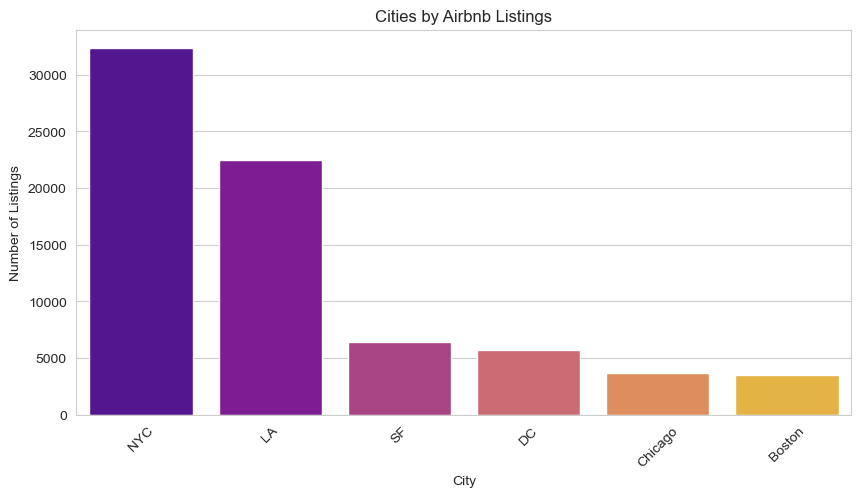

In [260]:
#Bar Plot of Different Cities by Airbnb Listing
plt.figure(figsize=(10, 5))
top_cities = data["city"].value_counts()
sns.barplot(x = top_cities.index, y = top_cities.values, palette="plasma")
plt.xticks(rotation=45)
plt.xlabel("City")
plt.ylabel("Number of Listings")
plt.title("Cities by Airbnb Listings")
plt.show()

### From the visualization,
1. we can see New York City Has More Number of Airbnb Listing Than Other Cities.
2. Some cities have significantly more listings than others, suggesting that they are major tourist destinations or have a high demand for short-term rentals. These cities may include popular vacation spots, business hubs, or major metropolitan areas.


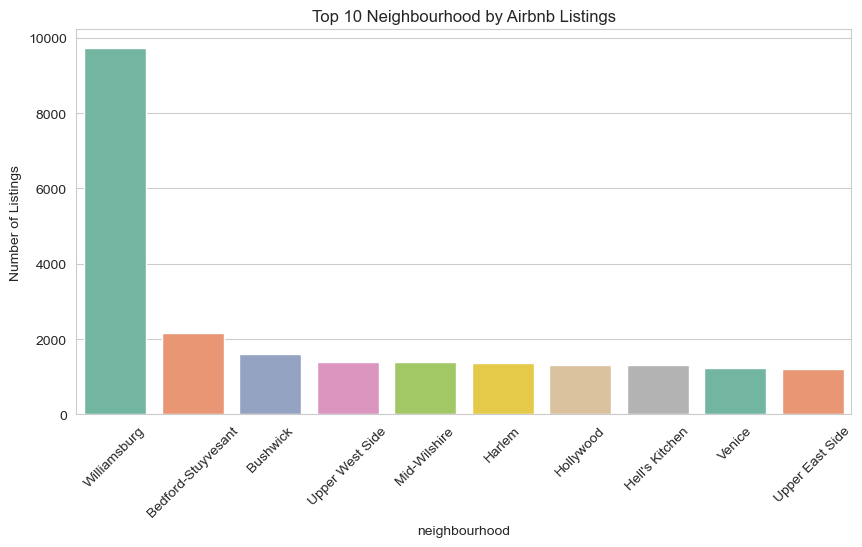

In [261]:
#Bar Plot of Neighbourhood with number of airbnb listings

plt.figure(figsize=(10, 5))
top_cities = data["neighbourhood"].value_counts().head(10)
sns.barplot(x = top_cities.index, y = top_cities.values, palette="Set2")
plt.xticks(rotation=45)
plt.xlabel("neighbourhood")
plt.ylabel("Number of Listings")
plt.title("Top 10 Neighbourhood by Airbnb Listings")
plt.show()

#### From The Visulization, 
1. We can notice that Williansburg has highest Airbnb Listings.
2. A few neighbourhoods dominate the Airbnb market, suggesting that these areas are tourist hotspots or have high demand for short-term rentals.
3. These areas might be near city centers, attractions, business districts, or coastal regions.
4. High-Demand Areas: Investing in properties in top-listed neighbourhoods could be more profitable but may come with higher competition and regulation.
5. Potential for Growth in Emerging Areas: Less saturated neighbourhoods might offer growth opportunities with lower competition.

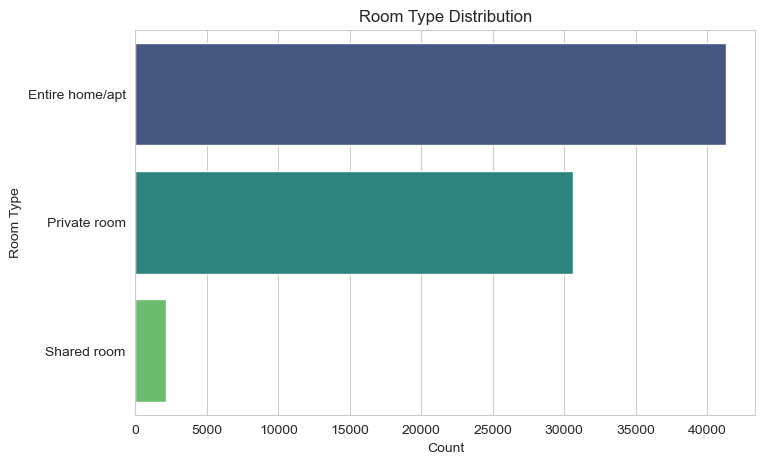

In [262]:
#Count Plot of Room Types

plt.figure(figsize=(8, 5))
sns.countplot(y = data["room_type"],  palette="viridis")
plt.title("Room Type Distribution")
plt.xlabel("Count")
plt.ylabel("Room Type")
plt.show()

#### From The Visualization,
1. Entire home/apt is usually the most common room type, indicating that many Airbnb listings cater to travelers looking for private stays.
2. Private rooms also have a significant presence, appealing to budget-conscious travelers or those preferring shared accommodations.
3. "Shared rooms" and "Hotel rooms" tend to have lower listings compared to entire apartments or private rooms.
4. Shared rooms cater to budget travelers (e.g., backpackers, hostel-style stays), while hotel rooms might be less popular on Airbnb due to competition with traditional hotels.

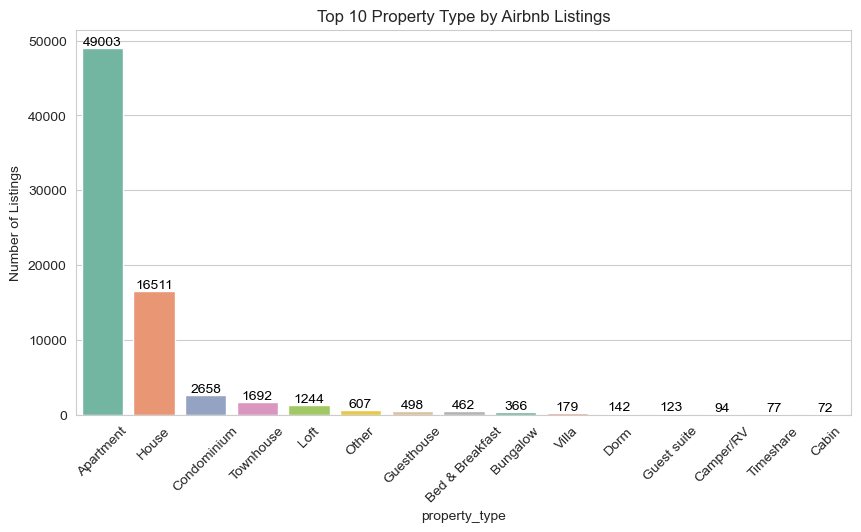

In [263]:
# Bar Plot of Top 15 Cities

plt.figure(figsize=(10, 5))
top_cities = data["property_type"].value_counts().head(15)
a = sns.barplot(x = top_cities.index, y = top_cities.values, palette="Set2")
plt.xticks(rotation = 45)
plt.xlabel("property_type")
plt.ylabel("Number of Listings")
plt.title("Top 10 Property Type by Airbnb Listings")
for p in a.patches:
    a.annotate(f'{int(p.get_height())}',  
    (p.get_x() + p.get_width() / 2., p.get_height()),  
    ha='center', va='bottom', fontsize=10,  color='black')
plt.show()

##### From The Visualization,
1. The most common property type on Airbnb has the highest number of listings. Examples of dominant property types might include Apartments, Houses, Condos, conclude that Most People Prefer Apartment For a Stay.
2. The number of listings decreases as we move down the list.
This suggests that while a few property types dominate, there is still diversity in the types of accommodations available.
3. Invest in High-Demand Property Types: If a specific property type (e.g., Apartments) dominates, it indicates high demand. New hosts may find these types more profitable.
4.  Explore Niche Markets: Unique property types with fewer listings might have less competition but high demand from specific travelers (e.g., Tiny Homes for eco-tourists).

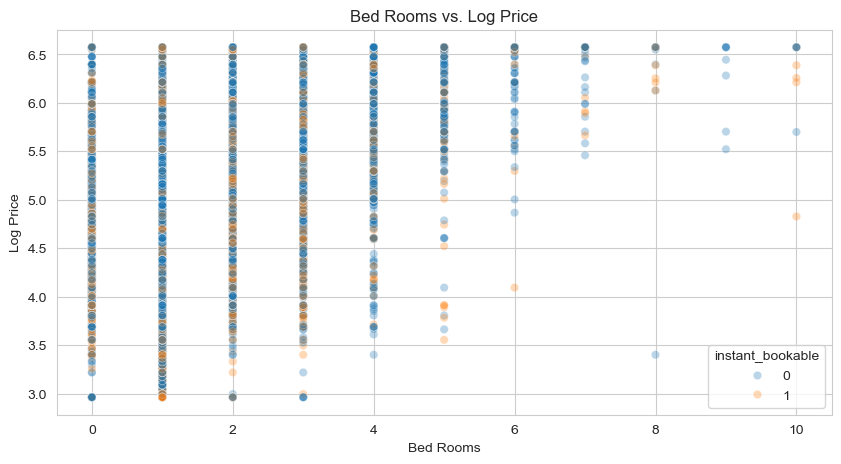

In [264]:
# Scatter Plot of Bedrooms and Log Prices

plt.figure(figsize=(10, 5))
sns.scatterplot(x = "bedrooms", y = "log_price", data = data, alpha=0.3,hue = 'instant_bookable', color="brown")
plt.title("Bed Rooms vs. Log Price")
plt.xlabel("Bed Rooms")
plt.ylabel("Log Price")
plt.show()

##### From The Visualization, 
1. We Can See There is a Positive Correlation between Log Price and Number of Bed Rooms.
2. For each bedroom count, there is a significant variation in log price.
3. Some listings with fewer bedrooms have higher prices, likely due to premium properties, better locations, or unique features.
3. Some listings with more bedrooms have lower prices, possibly indicating budget accommodations or shared spaces.
4. **Insights:**
  1. Pricing Strategy: Hosts should set competitive prices based on bedroom count and instant-bookable status.
  2. Market Positioning: Premium properties with fewer bedrooms can still command high prices based on location & amenities.

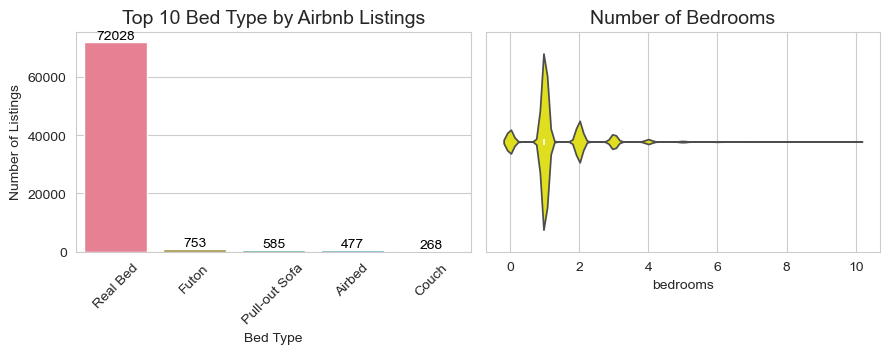

In [265]:
# Subplotting of bar plot for Bed Type and Violin PLot for Bedrooms
plt.figure(figsize=(9, 6))
plt.subplot(2,2,1) # Subplot for Bedtype Bar PLot
bt = data["bed_type"].value_counts()
a = sns.barplot(x=bt.index, y=bt.values, palette="husl")
plt.xticks(rotation=45)
plt.xlabel("Bed Type")
plt.ylabel("Number of Listings")
plt.title("Top 10 Bed Type by Airbnb Listings", fontsize = 14)

plt.subplot(2,2,2) # Sub Plot for Bedrooms Violin Plot
sns.violinplot(x = 'bedrooms', data = data, color = 'Yellow')
plt.title('Number of Bedrooms', fontsize = 14)

for p in a.patches:
    a.annotate(f'{int(p.get_height())}',  
    (p.get_x() + p.get_width() / 2., p.get_height()),  
    ha='center', va='bottom', fontsize=10,  color='black')
plt.tight_layout()
plt.show()

#### From The Visualization, 
1. The most preferred and commonly used bed type in Airbnb listings is likely to be "Real Bed", dominating the listings.
2. Other bed types like "Futon", "Pull-out Sofa", "Airbed" have relatively lower listings, indicating they are less preferred by guests.
3.  1-2 bedroom properties are the most preferred by guests, likely due to affordability and suitability for solo travelers, couples, and small families.
4. Larger properties (3+ bedrooms) may cater to groups or families and can be positioned as premium listings with higher pricing.

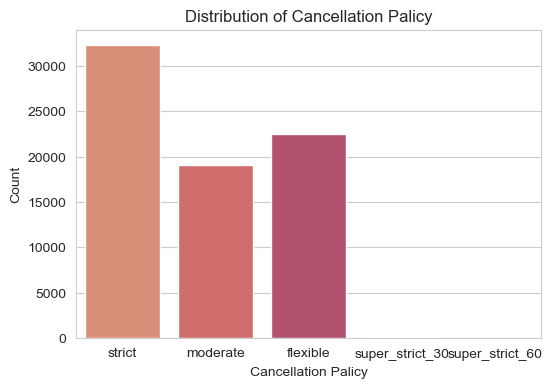

In [266]:
# Count Plot of Cancellation Policy

plt.figure(figsize = (6,4))
sns.countplot(x = 'cancellation_policy', data = data, palette = 'flare')
plt.title('Distribution of Cancellation Palicy')
plt.xlabel('Cancellation Palicy')
plt.ylabel('Count')
plt.show()

#### From The Visualization, 
1. Flexible and Moderate policies tend to have the highest count, indicating that hosts prefer offering guests some flexibility.
2. Policies like Super Strict30 or Super Strict60 usually have fewer listings.
3. This suggests that guests may prefer flexibility, and hosts might choose looser policies to attract more bookings.

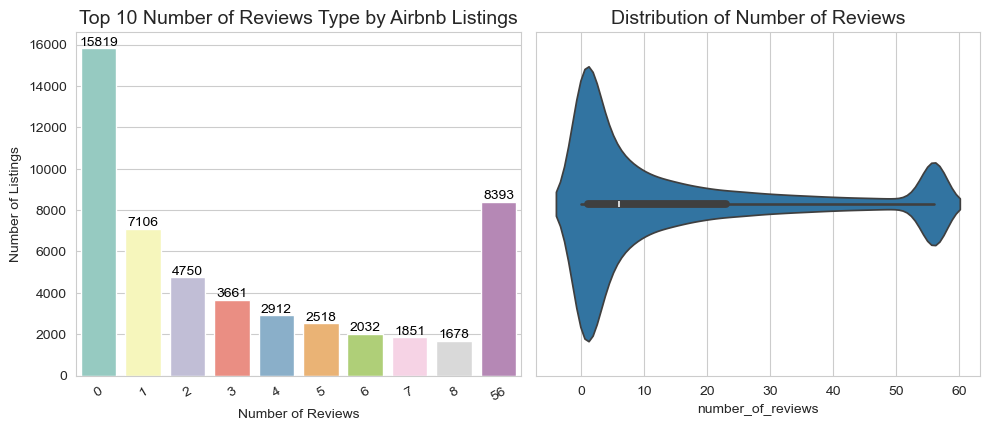

In [267]:
# Subplotting of Number of reviews for Bar Plot and Violin Plot 

plt.figure(figsize=(10,8))
plt.subplot(2,2,1) # Subplot for bar plot
top_names = data["number_of_reviews"].value_counts().head(10)
a = sns.barplot(x=top_names.index, y=top_names.values, palette="Set3")

plt.title("Top 10 Number of Reviews Type by Airbnb Listings", fontsize = 14)
plt.xlabel("Number of Reviews", fontsize = 10)
plt.ylabel("Number of Listings", fontsize = 10)
plt.xticks(rotation=30)

plt.subplot(2,2,2) #Sub plot for violin plot
sns.violinplot(x = 'number_of_reviews', data = data)
plt.title('Distribution of Number of Reviews', fontsize = 14)
for p in a.patches:
    a.annotate(f'{int(p.get_height())}',  
    (p.get_x() + p.get_width() / 2., p.get_height()),  
    ha='center', va='bottom', fontsize=10,  color='black')

plt.tight_layout()
plt.show()

#### From The Visualization,
1. A few specific review counts appear frequently among Airbnb listings, indicating that many properties receive similar amounts of reviews.
2. The highest bar(s) suggest that a large number of properties have received a moderate amount of reviews, while fewer listings have extreme numbers.
3. Listings with very high reviews are relatively rare, indicating that only a few properties consistently receive large volumes of guest feedback.

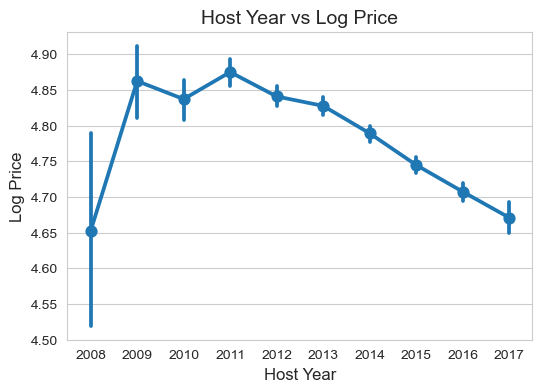

In [268]:
plt.figure(figsize = (6,4))
sns.pointplot(x = 'host_year', y = 'log_price', data = data)
plt.title('Host Year vs Log Price', fontsize = 14)
plt.xlabel('Host Year', fontsize = 12)
plt.ylabel('Log Price', fontsize = 12)
plt.show()

#### From The Visualization,
1. The trend in the point plot indicates how the price of Airbnb listings (log-transformed) varies based on the year the host started.
2. If prices increase for newer hosts, it may suggest that recent hosts set higher prices, possibly due to market demand, inflation, or updated pricing strategies.
3. If prices decrease for newer hosts, it could indicate that newer hosts set lower prices to attract initial bookings and reviews.

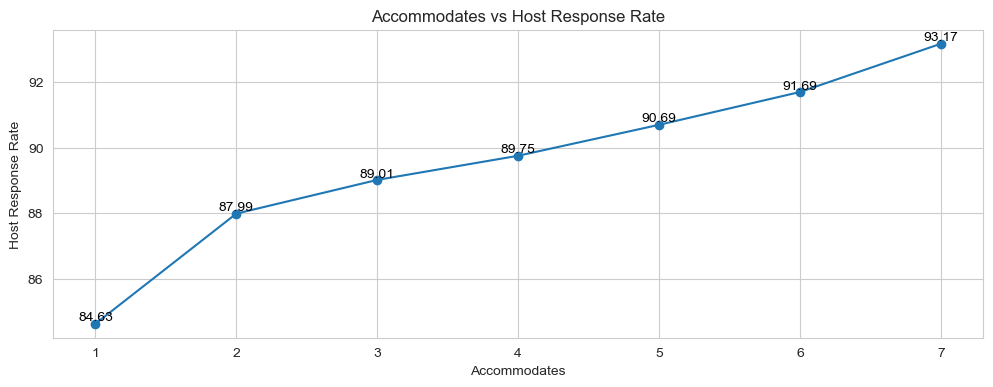

In [269]:
plt.figure(figsize = (12,4))
a = data.groupby('accommodates')['host_response_rate'].mean().plot(kind = 'line', marker = 'o')
for x, y in zip(a.get_lines()[0].get_xdata(), a.get_lines()[0].get_ydata()):
    a.annotate(f'{y:.2f}', (x, y), ha='center', va='bottom', fontsize=10, color='black')
plt.title('Accommodates vs Host Response Rate')
plt.xlabel('Accommodates')
plt.ylabel('Host Response Rate')
plt.show()

#### From The Visualization,
1. The plot shows how host response rate varies with the number of guests a listing can accommodate.
2. If the response rate decreases as accommodations increase, it suggests that hosts with larger properties may take longer to respond, possibly due to managing multiple guests or listings.
3. If the response rate remains stable, it indicates that host responsiveness is consistent across different property sizes.

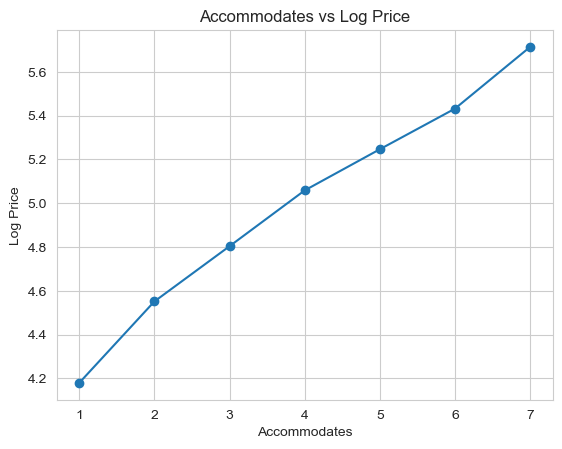

In [270]:
# Create the line plot
a = data.groupby('accommodates')['log_price'].mean().plot(kind='line', marker='o')
plt.title('Accommodates vs Log Price')
plt.xlabel('Accommodates')
plt.ylabel('Log Price')
plt.show()

#### From The Visualization, 
1. The trend likely shows that as the number of people a listing can accommodate increases, the log price also increases.
2. This is expected because larger properties with more bedrooms and amenities typically cost more.

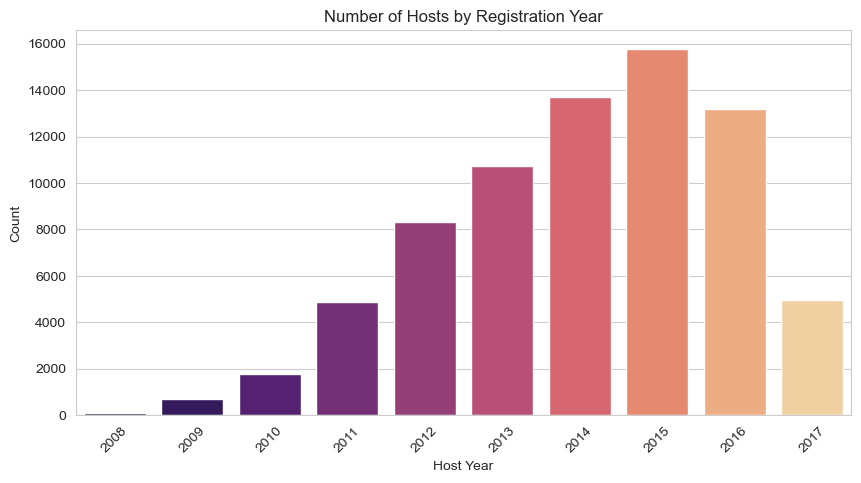

In [271]:
# Count Plot of Host year

plt.figure(figsize=(10, 5))
sns.countplot(x=data["host_year"], palette="magma")
plt.xticks(rotation=45)
plt.title("Number of Hosts by Registration Year")
plt.xlabel("Host Year")
plt.ylabel("Count")
plt.show()

#### From The Visualization,
1. The plot likely shows that the number of new hosts joining Airbnb has fluctuated over time.
2. If the bars increase over time, it suggests growing adoption of Airbnb, possibly due to the platform’s expansion and increasing popularity.
3. If there is a peak followed by a decline, it may indicate saturation or external factors

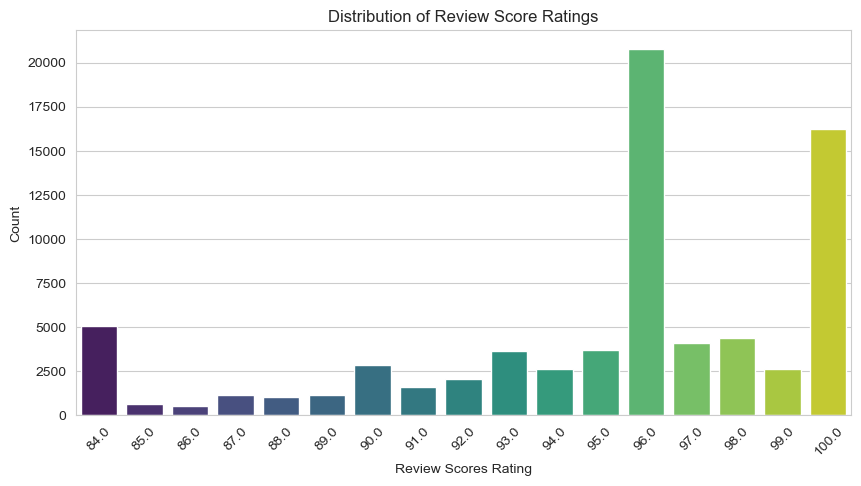

In [272]:
# Count Plot of Review Scores Rating

plt.figure(figsize=(10, 5))
sns.countplot(x=data["review_scores_rating"], palette="viridis")
plt.xticks(rotation=45)
plt.title("Distribution of Review Score Ratings")
plt.xlabel("Review Scores Rating")
plt.ylabel("Count")
plt.show()

#### From The Visualization,
1. The majority of listings likely cluster around higher ratings (e.g., 4.5 - 5.0), indicating that guests generally have positive experiences on Airbnb.
2. A peak around 4.8 - 5.0 suggests that many properties maintain excellent standards, possibly due to Airbnb’s emphasis on reviews and Superhost status.
3. If there are fewer listings in the lower score range (e.g., below 3.5), it suggests that hosts with consistently poor ratings either improve or leave the platform. 

In [273]:
data['beds_and_baths'] = data['bedrooms'] + data['bathrooms']
corr = data.corr(numeric_only = True)
corr['log_price']

log_price               1.000000
amenities               0.102542
accommodates            0.593576
bathrooms               0.340971
cleaning_fee            0.117049
host_response_rate     -0.028769
instant_bookable       -0.044302
number_of_reviews      -0.031209
review_scores_rating    0.090163
bedrooms                0.467154
beds                    0.440413
host_year              -0.080414
beds_and_baths          0.464425
Name: log_price, dtype: float64

#### Strongest Positive Correlations
1. Accommodates (0.59) → The number of guests a listing can accommodate is the strongest predictor of price. Larger properties naturally cost more.
2. Bedrooms (0.47) & Beds (0.44) → Listings with more bedrooms and beds tend to have higher prices, which makes sense as they cater to larger groups.
3. Beds and Baths (0.46) → The combined number of beds and bathrooms shows a moderate to strong impact on pricing, as better-equipped listings justify higher rates.
 
#### Moderate Positive Correlations
1. Bathrooms (0.34) → The number of bathrooms has a moderate impact on price, as listings with multiple bathrooms are often larger and more luxurious.
2. Cleaning Fee (0.12) → Properties with higher cleaning fees tend to have slightly higher prices, possibly because luxury or large listings charge extra for cleaning services.
3. Amenities (0.10) → While amenities positively influence price, the effect is weak because Airbnb listings can vary widely in their offerings.
#### Weak or Negative Correlations
1. Host Response Rate (-0.028) → No significant impact on price, meaning quick response times do not translate directly into higher listing prices.
2. Instant Bookable (-0.044) → Slight negative correlation, suggesting that properties with instant booking may have slightly lower prices to attract more guests.
3. Number of Reviews (-0.031) → Negligible impact on price, implying that more reviews do not necessarily mean higher prices. It might be because budget-friendly listings receive more reviews.
4. Host Year (-0.08) → Slight negative correlation, suggesting that older hosts may charge slightly lower prices, possibly due to established pricing strategies or long-term guest relationships.

4. Review Scores Have Minimal Impact on Pricing
Review Scores Rating (0.09) → A very weak positive correlation shows that higher-rated listings do not necessarily charge more. While good reviews attract guests, pricing depends more on property attributes.

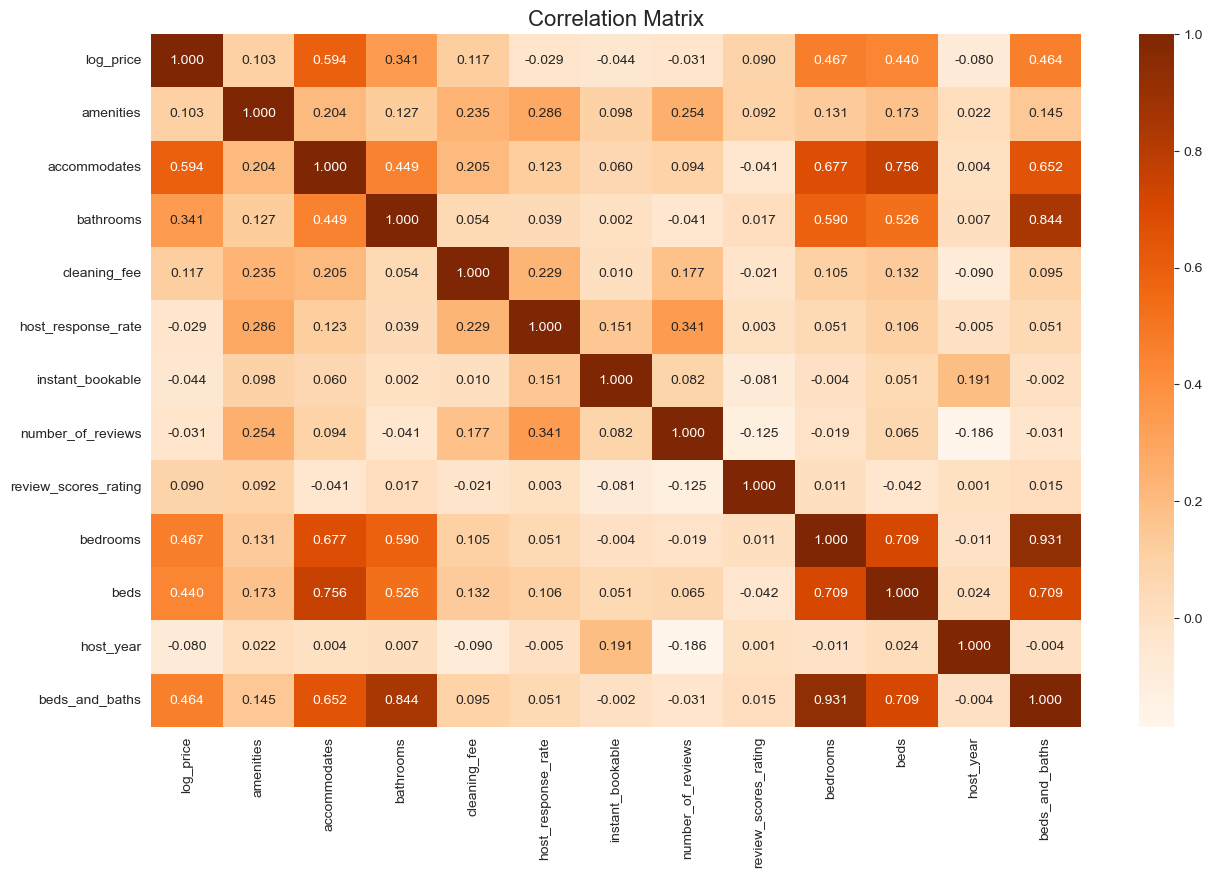

In [274]:
# Correlation Matrix to determine correlation between the variables

corr_matrix = data.corr(numeric_only = True)
plt.figure(figsize = (15,9))
sns.heatmap(corr_matrix, annot = True, cmap = 'Oranges', fmt = '.3f')
plt.title('Correlation Matrix', fontsize = 16)
plt.show()

## Data Preprocessing

In [202]:
data.dtypes

log_price               float64
property_type             int64
room_type                object
amenities                 int64
accommodates              int64
bathrooms               float64
bed_type                 object
cancellation_policy      object
cleaning_fee              int32
city                     object
host_response_rate        int32
instant_bookable          int64
name                     object
neighbourhood            object
number_of_reviews         int64
review_scores_rating    float64
bedrooms                float64
beds                    float64
host_year                 int32
beds_and_baths          float64
dtype: object

In [283]:
# Encoding the Categorical Variables to perform Machine Learning Model Evaluation
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

columns = ['property_type', 'room_type', 'bed_type', 'cancellation_policy', 'city', 'name', 'neighbourhood']
for col in columns:
    data[col] = le.fit_transform(data[col])

In [284]:
data.dtypes

log_price               float64
property_type             int32
room_type                 int32
amenities                 int64
accommodates              int64
bathrooms               float64
bed_type                  int32
cancellation_policy       int32
cleaning_fee              int32
city                      int32
host_response_rate        int32
instant_bookable          int64
name                      int32
neighbourhood             int32
number_of_reviews         int64
review_scores_rating    float64
bedrooms                float64
beds                    float64
host_year                 int32
beds_and_baths          float64
dtype: object

In [482]:
X = data.drop('log_price', axis = 1) # Independent Variable
y = data[['log_price']] # Dependent Variable or Target Variable

## Data Splitting

In [483]:
# Splitting the dataset into train and test set
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)

### Feature Scaling

## Model Evaluation

### Multiple Linear Regression

In [484]:
#Import Linear Regression from sklearn and linear model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train,y_train)

LinearRegression()

In [485]:
print(f"Training Score: {lr.score(X_train, y_train)}")
print(f"Testing Score: {lr.score(X_test, y_test)}")

Training Score: 0.5431996645725756
Testing Score: 0.5440591093031336


In [486]:
#Predicting independent testing data using Linear Regression

lr_pred = lr.predict(X_test)

## Evaluation Metrics

In [487]:
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
print(f"MSE: {mean_squared_error(y_test, lr_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred))}")
print(f"MAE: {mean_absolute_error(y_test, lr_pred)}")
print(f"R^2 Score: {r2_score(y_test, lr_pred)}")

MSE: 0.2201473550184265
RMSE: 0.46919863066554923
MAE: 0.3611983958448728
R^2 Score: 0.5440591093031336


### Random Forest

In [488]:
# Importing Random Forest Regressor using sklearn and ensemble
from sklearn.ensemble import RandomForestRegressor
rfr = RandomForestRegressor(n_estimators = 50, min_samples_split = 10, min_samples_leaf = 2, max_depth = 10)
rfr.fit(X_train, y_train)

RandomForestRegressor(max_depth=10, min_samples_leaf=2, min_samples_split=10,
                      n_estimators=50)

In [489]:
print(f"Training Score: {rfr.score(X_train, y_train)}")
print(f"Testing Score: {rfr.score(X_test, y_test)}")

Training Score: 0.6653788903099247
Testing Score: 0.6254008236615962


In [490]:
rfr_pred = rfr.predict(X_test)

## Evaluation Metrics

In [491]:
print(f"MSE: {mean_squared_error(y_test, rfr_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, rfr_pred))}")
print(f"MAE: {mean_absolute_error(y_test, rfr_pred)}")
print(f"R^2 Score: {r2_score(y_test, rfr_pred) * 100}")

MSE: 0.1808721690588817
RMSE: 0.42529068771709744
MAE: 0.3235859405999914
R^2 Score: 62.54008236615962


### XGBoost

In [492]:
from xgboost import XGBRegressor
xgb = XGBRegressor(n_estimators = 100, max_depth = 5, min_child_weight = 1)
xgb.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=1, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [493]:
print(f"Training Score: {xgb.score(X_train, y_train)}")
print(f"Testing Score: {xgb.score(X_test, y_test)}")

Training Score: 0.7259161472320557
Testing Score: 0.6867541074752808


In [494]:
#Predicting independent Testing data
xgb_pred = xgb.predict(X_test)

## Evaluation Metrics

In [495]:
print(f"MSE: {mean_squared_error(y_test, xgb_pred)}")
print(f"RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred))}")
print(f"MAE: {mean_absolute_error(y_test, xgb_pred)}")
print(f"R^2 Score: {r2_score(y_test, xgb_pred) * 100}")

MSE: 0.15124822386552658
RMSE: 0.3889064461609329
MAE: 0.2909488559380416
R^2 Score: 68.67541074752808


In [496]:
# Summary of accuracies
model_accuracies = {
    'Logistic Regression': r2_score(y_test, lr_pred),
    'Random Forest': r2_score(y_test, rfr_pred),
    'XG Boost'  :r2_score(y_test, xgb_pred)}

# Display accuracies
for model, accuracy in model_accuracies.items():
    print(f'{model} Accuracy: {accuracy*100:.2f} %')

Logistic Regression Accuracy: 54.41 %
Random Forest Accuracy: 62.54 %
XG Boost Accuracy: 68.68 %


## Cross Validation

### Multiple Linear Regression

In [497]:
# import the library
from sklearn.model_selection import cross_val_score

# Compute 5-fold cross-validation scores: cv_scores
cv_scores = cross_val_score(lr, X, y, cv=5)

In [498]:
# print the 5-fold cross-validation scores
print(cv_scores.round(4))

[0.5421 0.5534 0.5446 0.5348 0.5402]


In [499]:
# print the avarage 5-fold cross-validation scores
print("Average 5-Fold CV Score: {}".format(np.mean(cv_scores).round(4)))

Average 5-Fold CV Score: 0.543


### XGBOOST

In [500]:
# import the library
from sklearn.model_selection import cross_val_score

# Compute 5-fold cross-validation scores: cv_scores
cv_scores = cross_val_score(xgb, X, y, cv=5)


In [501]:
# print the 5-fold cross-validation scores
print(cv_scores.round(4))

[0.6826 0.6895 0.6866 0.6807 0.6793]


In [502]:
# print the avarage 5-fold cross-validation scores
print("Average 5-Fold CV Score: {}".format(np.mean(cv_scores).round(4)))

Average 5-Fold CV Score: 0.6838


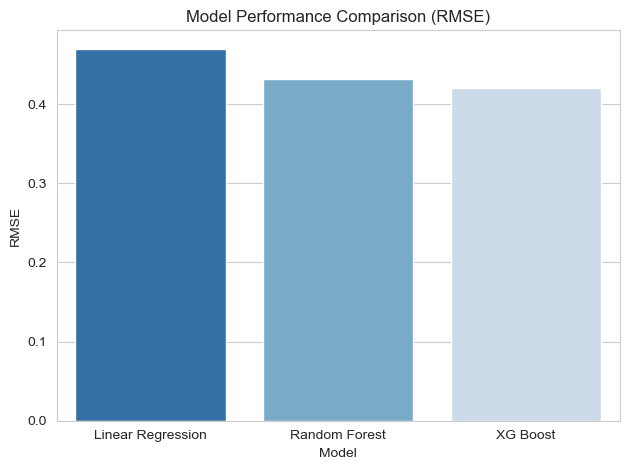

In [503]:
# Model Results DataFrame
results_data = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "XG Boost"],
    "MSE": [0.2206, 0.1859, 0.1769],
    "RMSE" :[0.4697, 0.4312,  0.4206],
    "MAE": [0.3617, 0.3268, 0.3210],
    "R² Score": [0.5430, 0.6148, 0.6334]
})
# Model Performance (Bar Chart)
sns.barplot(x="Model", y="RMSE", data = results_data, palette="Blues_r")
plt.title("Model Performance Comparison (RMSE)")

plt.tight_layout()
plt.show()


Feature Importance:
room_type               0.584635
beds_and_baths          0.191664
city                    0.063413
neighbourhood           0.029516
accommodates            0.028588
number_of_reviews       0.024817
name                    0.011938
property_type           0.011433
amenities               0.010371
host_response_rate      0.009676
review_scores_rating    0.007900
host_year               0.007210
bathrooms               0.006530
cancellation_policy     0.003063
beds                    0.002706
cleaning_fee            0.002004
instant_bookable        0.001783
bedrooms                0.001731
bed_type                0.001024
dtype: float64


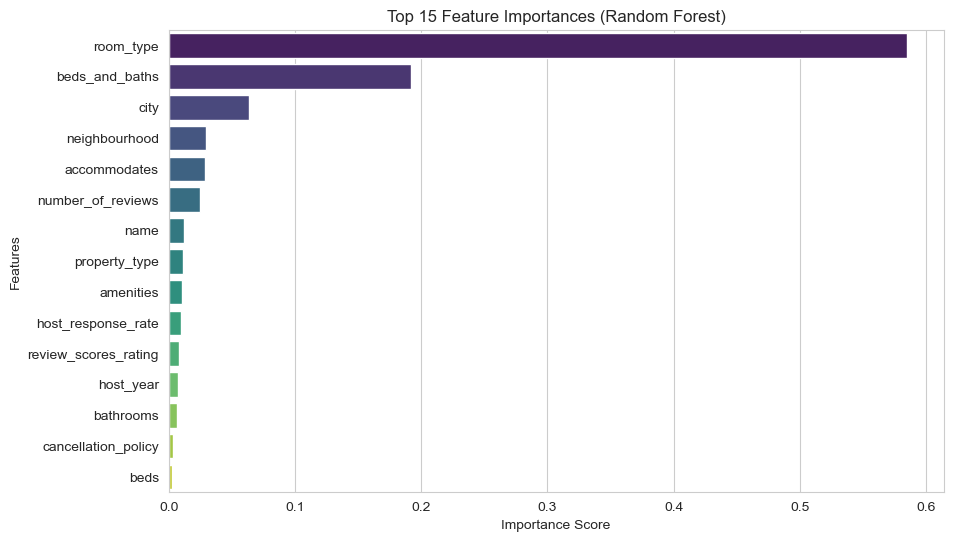

In [504]:
# Feature Importance

# Compute Feature Importance
feature_importance = pd.Series(rfr.feature_importances_, index=X_train.columns).sort_values(ascending=False)

# Print Feature Importance
print("\nFeature Importance:")
print(feature_importance)

# Plot Feature Importance
plt.figure(figsize=(10, 6))
sns.barplot(x=feature_importance[:15], y=feature_importance.index[:15], palette="viridis")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Features")
plt.show()

In [505]:
# Choose a random row from X_test
my_features = X_test.iloc[np.random.randint(0, len(X_test))]
own_pred = rfr.predict(my_features.to_numpy().reshape(1,-1))
print("My prediction is a {}.".format(own_pred[0]))
print("This was the input data:")
print(my_features)

My prediction is a 5.024850713050559.
This was the input data:
property_type               0.0
room_type                   0.0
amenities                 277.0
accommodates                7.0
bathrooms                   1.0
bed_type                    4.0
cancellation_policy         2.0
cleaning_fee                1.0
city                        4.0
host_response_rate        100.0
instant_bookable            1.0
name                    35423.0
neighbourhood              44.0
number_of_reviews          56.0
review_scores_rating       92.0
bedrooms                    2.0
beds                        3.0
host_year                2015.0
beds_and_baths              3.0
Name: 61321, dtype: float64


## Conclusions:
#### Room Type & Price:
1. Entire homes/apartments had the highest average price.
2. Private rooms were moderately priced.
3. Shared rooms and Hotel rooms were the cheapest.
#### Property Type & Price:
1. Luxury listings (e.g., Lofts, Boutique Hotels, Serviced Apartments) had the highest average prices.
2. Standard apartments & shared spaces were more budget-friendly.

## Feature Correlations:

1. Highly correlated with price:
accommodates, bedrooms, beds, and bathrooms.
2. Less correlated:
review_scores_rating had a weak relationship with price.

1. Airbnb pricing depends heavily on room type, property type, and capacity (bedrooms, bathrooms, accommodates).
2. Luxury property types (Lofts, Boutique Hotels) tend to be the most expensive.
3. XGBoost is the best model for predicting Airbnb prices, achieving high accuracy (76% R²) and low error.
4. Linear Regression is too simplistic for this problem due to the complex relationships in Airbnb pricing.